In [1]:
import GeoLeoXtract as glx
from importlib import reload
import numpy as np
import pathlib as pl

File /home/hagen/.GeoLeoXtract not found.


In [38]:
reload(glx.scrapers.hrrr)
reload(glx.cloud_interface)

<module 'GeoLeoXtract.cloud_interface' from '/home/hagen/prog/GeoLeoXtract/GeoLeoXtract/cloud_interface.py'>

In [39]:
gs = glx.scrapers.hrrr.Scraper(p2fld_out='/home/hagen/tmp/hrrr/res',
                               pattern='projected_{date}.nc',
                               p2fld_tmp='/home/hagen/tmp/hrrr/tmp',
                               frequency='D',
                               start='2022-01-01',
                               end='2024-01-01',
                               forcast_intervals=[0],
                               stations=None,
                               reporter=None,
                              )

In [40]:
# Thise are the files that need to be created, which implies that they do not exist yet!!
gs.workplan

,p2f_out
datetime,
2022-01-01,/home/hagen/tmp/hrrr/res/projected_20220101.nc
2022-01-02,/home/hagen/tmp/hrrr/res/projected_20220102.nc
2022-01-03,/home/hagen/tmp/hrrr/res/projected_20220103.nc
2022-01-04,/home/hagen/tmp/hrrr/res/projected_20220104.nc
2022-01-05,/home/hagen/tmp/hrrr/res/projected_20220105.nc
...,...
2023-12-28,/home/hagen/tmp/hrrr/res/projected_20231228.nc
2023-12-29,/home/hagen/tmp/hrrr/res/projected_20231229.nc
2023-12-30,/home/hagen/tmp/hrrr/res/projected_20231230.nc


In [41]:
query = gs.process_single_chunk(gs.workplan.iloc[0], what2return='query')

In [42]:
query.workplan = query.workplan.iloc[[0]]

In [43]:
query.workplan

,files_on_ftp,cycle_datetime,forcast_interval,path2tempfile,path2file,output_file_exits
0,noaa-hrrr-bdp-pds/hrrr.20220101/conus/hrrr.t00...,2022-01-01,0,~/tmp/hrrr_scraper/raw/hrrr.t00z.wrfnatf00.202...,/home/hagen/tmp/hrrr/tmp/20220101_00_fi00.nc,False


In [293]:
query.download()

[None]

In [96]:
if 0:
    p2fraw = row.path2tempfile.expanduser()
    p2finter =  row.path2file
else:
    p2fraw = pl.Path('~/tmp/hrrr_scraper/raw/hrrr.t00z.wrfnatf00.grib2').expanduser()
    p2finter = pl.Path('/home/hagen/tmp/hrrr/tmp/20220101_00_fi00.nc')

In [ ]:
si = glx.file_io_hrrr.open_grib_file(p2fraw, 
                                     # parameter_subset=['aerosol_mass_density_vp','precipitable_water_column'],
                                     raise_error_when_varible_missing = False,
                                     verbose = False
                                    )

In [103]:
si.ds

<xarray.Dataset> Size: 6GB
Dimensions:                                        (y: 1059, x: 1799, level: 50)
Coordinates:
    lat                                            (y, x) float32 8MB 21.14 ....
    lon                                            (y, x) float32 8MB -122.7 ...
  * level                                          (level) int64 400B 1 2 ... 50
Dimensions without coordinates: y, x
Data variables: (12/41)
    aerosol_mass_density_vp                        (level, y, x) float32 381MB ...
    specific_humidity_vp                           (level, y, x) float32 381MB ...
    fraction_of_cloud_cover_vp                     (level, y, x) float32 381MB ...
    level_height_geo_potential_vp                  (level, y, x) float32 381MB ...
    temperature_vp                                 (level, y, x) float32 381MB ...
    pressure_vp                                    (level, y, x) float32 381MB ...
    ...                                             ...
    total_cloud_cover                              (y, x) float32 8MB 16.0 .....
    aerosol_optical_depth                          (y, x) float32 8MB 0.0 ......
    cloud_base_gph                                 (y, x) float32 8MB nan ......
    cloud_top_gph                                  (y, x) float32 8MB nan ......
    composite_reflectivity                         (y, x) float32 8MB -10.0 ....
    DQF                                            (level, y, x) float32 381MB ...
Attributes:
    forecast_time:   00
    cycle_datetime:  2022-01-01 00:00:00
    title:           HRRR

In [ ]:
extent = [-123, 28, -103, 45] #[sw_lon, sw_lat, sw_lon, sw_lat]
proj = si.project_on_bounding_box(extent)
proj.ds

In [105]:
proj.ds

<xarray.Dataset> Size: 2GB
Dimensions:                                        (level: 50, y: 720, x: 693)
Coordinates:
    lat                                            (y, x) float32 2MB 25.19 ....
    lon                                            (y, x) float32 2MB -122.1 ...
  * level                                          (level) int64 400B 1 2 ... 50
Dimensions without coordinates: y, x
Data variables: (12/41)
    aerosol_mass_density_vp                        (level, y, x) float32 100MB ...
    specific_humidity_vp                           (level, y, x) float32 100MB ...
    fraction_of_cloud_cover_vp                     (level, y, x) float32 100MB ...
    level_height_geo_potential_vp                  (level, y, x) float32 100MB ...
    temperature_vp                                 (level, y, x) float32 100MB ...
    pressure_vp                                    (level, y, x) float32 100MB ...
    ...                                             ...
    total_cloud_cover                              (y, x) float32 2MB nan ......
    aerosol_optical_depth                          (y, x) float32 2MB nan ......
    cloud_base_gph                                 (y, x) float32 2MB nan ......
    cloud_top_gph                                  (y, x) float32 2MB nan ......
    composite_reflectivity                         (y, x) float32 2MB nan ......
    DQF                                            (level, y, x) float32 100MB ...
Attributes:
    forecast_time:   00
    cycle_datetime:  2022-01-01 00:00:00
    title:           HRRR

AttributeError: 'DataArray' object has no attribute 'long_name'

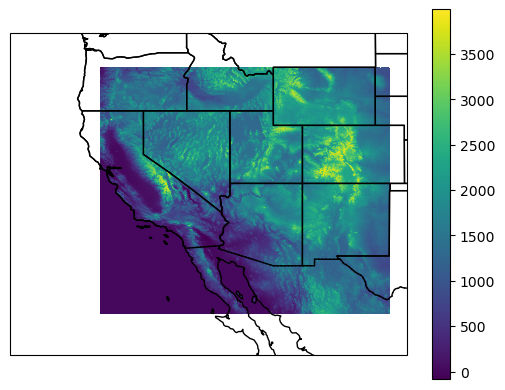

In [104]:
proj.plot('orography')

In [106]:
ds_out = proj.ds.drop_vars('DQF')

In [109]:
24*4*365*2

70080

In [107]:
ds_out

<xarray.Dataset> Size: 1GB
Dimensions:                                        (level: 50, y: 720, x: 693)
Coordinates:
    lat                                            (y, x) float32 2MB 25.19 ....
    lon                                            (y, x) float32 2MB -122.1 ...
  * level                                          (level) int64 400B 1 2 ... 50
Dimensions without coordinates: y, x
Data variables: (12/40)
    aerosol_mass_density_vp                        (level, y, x) float32 100MB ...
    specific_humidity_vp                           (level, y, x) float32 100MB ...
    fraction_of_cloud_cover_vp                     (level, y, x) float32 100MB ...
    level_height_geo_potential_vp                  (level, y, x) float32 100MB ...
    temperature_vp                                 (level, y, x) float32 100MB ...
    pressure_vp                                    (level, y, x) float32 100MB ...
    ...                                             ...
    precipitable_water_column                      (y, x) float32 2MB nan ......
    total_cloud_cover                              (y, x) float32 2MB nan ......
    aerosol_optical_depth                          (y, x) float32 2MB nan ......
    cloud_base_gph                                 (y, x) float32 2MB nan ......
    cloud_top_gph                                  (y, x) float32 2MB nan ......
    composite_reflectivity                         (y, x) float32 2MB nan ......
Attributes:
    forecast_time:   00
    cycle_datetime:  2022-01-01 00:00:00
    title:           HRRR

In [108]:
proj.ds.to_netcdf(p2finter)

# open it

In [1]:
import GeoLeoXtract as glx
import GeoLeoXtract.file_io_hrrr
from importlib import reload
import pathlib as pl

File /home/hagen/.GeoLeoXtract not found.


In [79]:
reload(glx.satlab)
# reload(glx.opt_imports)
reload(glx.file_io_hrrr)

<module 'GeoLeoXtract.file_io_hrrr' from '/home/hagen/prog/GeoLeoXtract/GeoLeoXtract/file_io_hrrr.py'>

In [80]:
# p2f = row.path2tempfile.expanduser()

p2f = pl.Path('~/tmp/hrrr_scraper/raw/hrrr.t00z.wrfnatf00.grib2').expanduser()

2-D fields: 
* terrain elevation (only for one time)            >>> orography
* surface pressure                                 >>> surface_pressure_surface
* surface precipitation rate                       >>> precipitation_rate_surface
* accumulated surface precipitation                >>> N/A
* snow depth                                       >>> snow_depth_surface
* surface temperature                              >>> temperature_surface (There is only one surfad temperature and its not clear to me at which hight 10 or 2!?!?)
* 10-m u                                           >>> wind_speed_gust_surface ... the wind vector for the ground do not seem to be included, only gust windspeeds
* v winds                                          >>> see above
* 2-m air temperature                              >>> see note at surface temperatur 
* 2-m relative humidity (or absolute humidity)     >>> N/A
* cloud fraction                                   >>> total_cloud_cover
* vertically integrated water vapor                >>> precipitable_water_column
b) 3-D fields:
* air temperature                                  >>> temperature_vp
* absolute humidity (or mixing ratio)              >>>
* u,v wind components (or wind speed & direction), >>>
* vertical velocity (or omega)                     >>>
* ice mixing ratio                                 >>>
* liquid water mixing ratio                        >>>
* pressure (or height if on pressure levels)       >>>


In [90]:
si = glx.file_io_hrrr.open_grib_file(p2f, 
                                     # parameter_subset=['aerosol_mass_density_vp','precipitable_water_column'],
                                     raise_error_when_varible_missing = False,
                                     verbose = False
                                    )

2d problem: {'name': 'Upward short-wave radiation flux', 'typeOfLevel': 'surface'} ... skip


# Do some projections

In [37]:
site = {'abb': 'TBL', 'name': 'Table Mountain (CO)', 'lat': 40.12498,
                            'lon': -105.2368,# this is the real one
                            # 'lon': -104., # just for playing around
                           }

In [38]:
proj = si.project_on_sites(site)

In [40]:
proj.projection2point

<xarray.DataArray 'orography' (site: 1)> Size: 4B
array([1652.2947], dtype=float32)
Coordinates:
  * site     (site) object 8B 'TBL'
Attributes: (12/15)
    parameterCategory:  3
    parameterNumber:    5
    parameterUnits:     gpm
    parameterName:      Geopotential height
    paramIdECMF:        228002
    paramId:            228002
    ...                 ...
    units:              m
    nameECMF:           Orography
    name:               Orography
    cfNameECMF:         geopotential_height
    cfName:             geopotential_height
    cfVarName:          orog

# set boundaries by lat lon corners

The most common way to define an area using latitude and longitude is by specifying the lower-left (SW) and upper-right (NE) corner coordinates.

In [82]:
1) region: lat: 28-45 N; lon: 103 W - 123 W; pressure top = 200 hPa

SyntaxError: unmatched ')' (1503247132.py, line 1)

In [ ]:
extent = [-123, 28, -103, 45] #[sw_lon, sw_lat, sw_lon, sw_lat]

proj = si.project_on_bounding_box(extent)

proj.ds

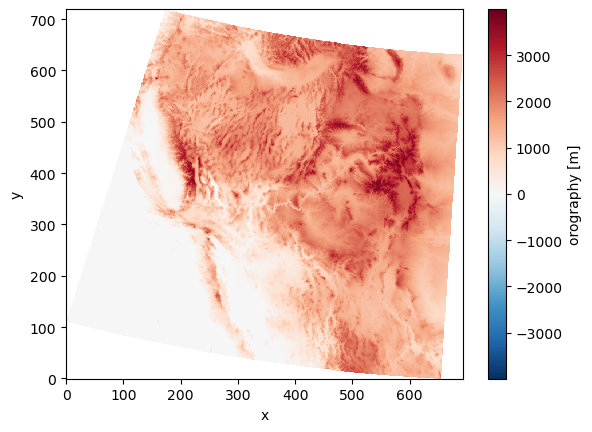

In [94]:
proj.ds.orography.plot()

In [53]:
import numpy as np

In [43]:
ds = si.ds.copy()

In [ ]:
dlon = dlat = 1
sw_lon, sw_lat = site['lon'] - dlon, site['lat'] - dlat
ne_lon, ne_lat = site['lon'] + dlon, site['lat'] + dlat

dst = ds.where(
    (ds.lon > sw_lon) & (ds.lon < ne_lon) & 
    (ds.lat > sw_lat) & (ds.lat < ne_lat), 
    drop=True
)

In [63]:
dlon = dlat = 1
sw_lon = site['lon'] - dlon
sw_lat = site['lat'] - dlat
ne_lon = site['lon'] + dlon
ne_lat = site['lat'] + dlat

dst = ds.where(
    (ds.lon > sw_lon) & (ds.lon < ne_lon) & 
    (ds.lat > sw_lat) & (ds.lat < ne_lat), 
    drop=True
)

In [ ]:
where1= ds.lon > sw_lon 
where2= ds.lat > sw_lat 
where3= ds.lon < ne_lon 
where4= ds.lat < ne_lat 
where12 = np.logical_and(where1,where2)
where34 = np.logical_and(where3,where4)
where = np.logical_and(where12,where34)
dst = ds.where(where, drop = True)


    (ds.lon > sw_lon) & (ds.lon < ne_lon) & 
    (ds.lat > sw_lat) & (ds.lat < ne_lat), 
    drop=True

In [ ]:
dlon = dlat = 1
sw_lon = site['lon'] - dlon
sw_lat = site['lat'] - dlat
ne_lon = site['lon'] + dlon
ne_lat = site['lat'] + dlat
sw_lon, sw_lat, ne_lon, ne_lat

where1= ds.lon > sw_lon 
where2= ds.lat > sw_lat 
where3= ds.lon < ne_lon 
where4= ds.lat < ne_lat 
where12 = np.logical_and(where1,where2)
where34 = np.logical_and(where3,where4)
where = np.logical_and(where12,where34)
dst = ds.where(where, drop = True)

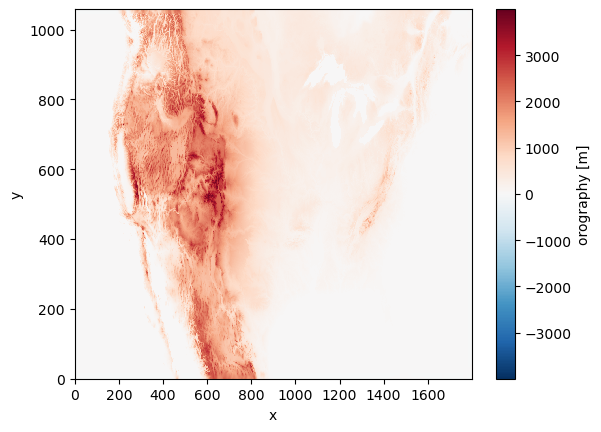

In [64]:
ds.orography.plot()

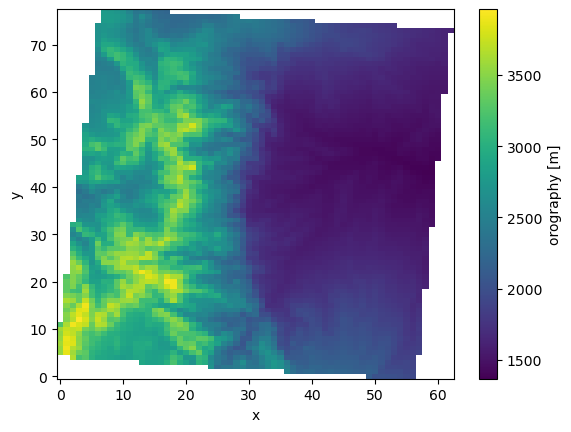

In [65]:
dst.orography.plot()

In [62]:
dst

<xarray.Dataset> Size: 15MB
Dimensions:                                        (level: 50, y: 78, x: 63)
Coordinates:
    lat                                            (y, x) float32 20kB 39.01 ...
    lon                                            (y, x) float32 20kB -106.2...
  * level                                          (level) int64 400B 1 2 ... 50
Dimensions without coordinates: y, x
Data variables: (12/41)
    aerosol_mass_density_vp                        (level, y, x) float32 983kB ...
    specific_humidity_vp                           (level, y, x) float32 983kB ...
    fraction_of_cloud_cover_vp                     (level, y, x) float32 983kB ...
    level_height_geo_potential_vp                  (level, y, x) float32 983kB ...
    temperature_vp                                 (level, y, x) float32 983kB ...
    pressure_vp                                    (level, y, x) float32 983kB ...
    ...                                             ...
    total_cloud_cover                              (y, x) float32 20kB nan .....
    aerosol_optical_depth                          (y, x) float32 20kB nan .....
    cloud_base_gph                                 (y, x) float32 20kB nan .....
    cloud_top_gph                                  (y, x) float32 20kB nan .....
    composite_reflectivity                         (y, x) float32 20kB nan .....
    DQF                                            (level, y, x) float32 983kB ...
Attributes:
    forecast_time:   00
    cycle_datetime:  2022-01-01 00:00:00
    title:           HRRR

In [58]:
where1= ds.lon > sw_lon 
where2= ds.lat > sw_lat 
where3= ds.lon < ne_lon 
where4= ds.lat < ne_lat 
where12 = np.logical_and(where1,where2)
where34 = np.logical_and(where3,where4)
where = np.logical_and(where12,where34)
dst = ds.where(where)

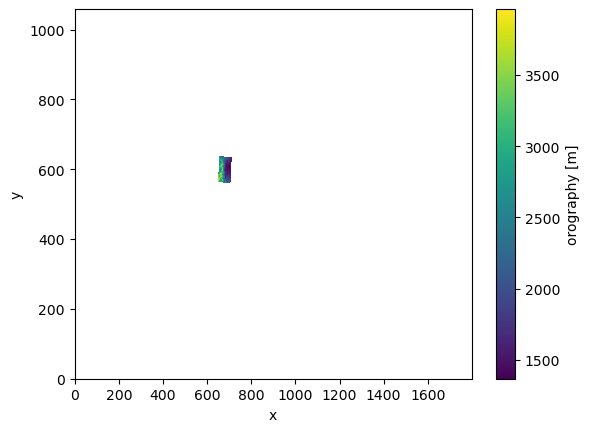

In [59]:
dst.orography.plot()

In [86]:
ds

<xarray.Dataset> Size: 6GB
Dimensions:                                        (x: 1059, y: 1799, level: 50)
Coordinates:
    lat                                            (x, y) float32 8MB 21.14 ....
    lon                                            (x, y) float32 8MB -122.7 ...
  * level                                          (level) int64 400B 1 2 ... 50
Dimensions without coordinates: x, y
Data variables: (12/40)
    aerosol_mass_density_vp                        (level, x, y) float32 381MB ...
    specific_humidity_vp                           (level, x, y) float32 381MB ...
    fraction_of_cloud_cover_vp                     (level, x, y) float32 381MB ...
    level_height_geo_potential_vp                  (level, x, y) float32 381MB ...
    temperature_vp                                 (level, x, y) float32 381MB ...
    pressure_vp                                    (level, x, y) float32 381MB ...
    ...                                             ...
    precipitable_water_column                      (x, y) float32 8MB 14.82 ....
    total_cloud_cover                              (x, y) float32 8MB 16.0 .....
    aerosol_optical_depth                          (x, y) float32 8MB 0.0 ......
    cloud_base_gph                                 (x, y) float32 8MB nan ......
    cloud_top_gph                                  (x, y) float32 8MB nan ......
    composite_reflectivity                         (x, y) float32 8MB -10.0 ....
Attributes:
    forecast_time:   00
    cycle_datetime:  2022-01-01 00:00:00
    title:           HRRR

# Create the child of satellite instance

In [9]:
import xarray as xr

In [10]:
ds

<xarray.Dataset> Size: 6GB
Dimensions:                                        (y: 1059, x: 1799, level: 50)
Coordinates:
    lat                                            (y, x) float32 8MB 21.14 ....
    lon                                            (y, x) float32 8MB -122.7 ...
  * level                                          (level) int64 400B 1 2 ... 50
Dimensions without coordinates: y, x
Data variables: (12/40)
    aerosol_mass_density_vp                        (level, y, x) float32 381MB ...
    specific_humidity_vp                           (level, y, x) float32 381MB ...
    fraction_of_cloud_cover_vp                     (level, y, x) float32 381MB ...
    level_height_geo_potential_vp                  (level, y, x) float32 381MB ...
    temperature_vp                                 (level, y, x) float32 381MB ...
    pressure_vp                                    (level, y, x) float32 381MB ...
    ...                                             ...
    precipitable_water_column                      (y, x) float32 8MB 14.82 ....
    total_cloud_cover                              (y, x) float32 8MB 16.0 .....
    aerosol_optical_depth                          (y, x) float32 8MB 0.0 ......
    cloud_base_gph                                 (y, x) float32 8MB nan ......
    cloud_top_gph                                  (y, x) float32 8MB nan ......
    composite_reflectivity                         (y, x) float32 8MB -10.0 ....
Attributes:
    forecast_time:   00
    cycle_datetime:  2022-01-01 00:00:00
    title:           HRRR

In [11]:
ds['DQF'] = xr.zeros_like(ds[max(ds.data_vars, key=lambda var: len(ds[var].dims))])


In [12]:
reload(glx.satlab)
# reload(glx.opt_imports)
reload(glx.file_io_hrrr)

<module 'GeoLeoXtract.file_io_hrrr' from '/home/hagen/prog/GeoLeoXtract/GeoLeoXtract/file_io_hrrr.py'>

In [13]:
si = glx.satlab.HRRR(ds, 
                product_version = 0, #can find what HRRR version is actually producing the grib file
               )

In [22]:
proj.projection2point.orography

<xarray.DataArray 'orography' (site: 1)> Size: 4B
array([1652.2947], dtype=float32)
Coordinates:
  * site     (site) object 8B 'TBL'
Attributes: (12/15)
    parameterCategory:  3
    parameterNumber:    5
    parameterUnits:     gpm
    parameterName:      Geopotential height
    paramIdECMF:        228002
    paramId:            228002
    ...                 ...
    units:              m
    nameECMF:           Orography
    name:               Orography
    cfNameECMF:         geopotential_height
    cfName:             geopotential_height
    cfVarName:          orog

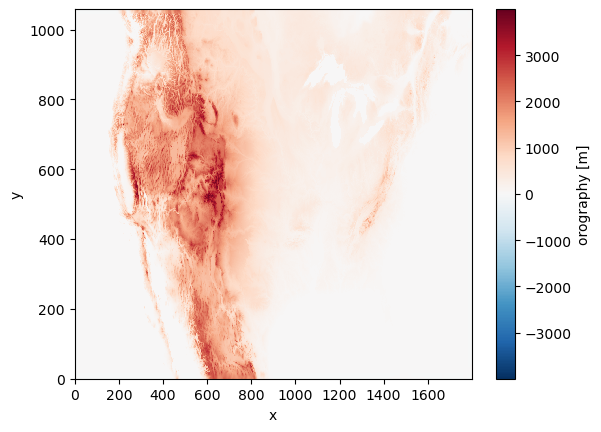

In [24]:
si.ds.orography.plot(x = 'x')


In [238]:
proj.grid.ds.title

'HRRR'

In [239]:
proj.projection2point

<xarray.Dataset> Size: 3kB
Dimensions:                                        (site: 1, level: 50)
Coordinates:
  * site                                           (site) object 8B 'TBL'
Dimensions without coordinates: level
Data variables: (12/49)
    aerosol_mass_density_vp                        (site, level) float32 200B ...
    specific_humidity_vp                           (site, level) float32 200B ...
    fraction_of_cloud_cover_vp                     (site, level) float32 200B ...
    level_height_geo_potential_vp                  (site, level) float32 200B ...
    temperature_vp                                 (site, level) float32 200B ...
    pressure_vp                                    (site, level) float32 200B ...
    ...                                             ...
    argmin_y                                       (site) float32 4B 715.0
    lon_gritpoint                                  (site) float32 4B -104.0
    lat_gridpoint                                  (site) float32 4B 40.13
    lon_station                                    (site) float32 4B -104.0
    lat_station                                    (site) float32 4B 40.12
    distance_station_gridpoint                     (site) float32 4B 0.4644
Attributes:
    forecast_time:   00
    cycle_datetime:  2022-01-01 00:00:00
    title:           HRRR

In [176]:
proj.closest_grid_points

ValueError: conflicting sizes for dimension 'x': length 1799 on the data but length 1059 on coordinate 'x'

In [164]:
ds

<xarray.Dataset> Size: 6GB
Dimensions:                                        (x: 1059, y: 1799, level: 50)
Coordinates:
    lat                                            (x, y) float32 8MB 21.14 ....
    lon                                            (x, y) float32 8MB -122.7 ...
  * level                                          (level) int64 400B 1 2 ... 50
Dimensions without coordinates: x, y
Data variables: (12/42)
    aerosol_mass_density_vp                        (level, x, y) float32 381MB ...
    specific_humidity_vp                           (level, x, y) float32 381MB ...
    fraction_of_cloud_cover_vp                     (level, x, y) float32 381MB ...
    level_height_geo_potential_vp                  (level, x, y) float32 381MB ...
    temperature_vp                                 (level, x, y) float32 381MB ...
    pressure_vp                                    (level, x, y) float32 381MB ...
    ...                                             ...
    aerosol_optical_depth                          (x, y) float32 8MB 0.0 ......
    cloud_base_gph                                 (x, y) float32 8MB nan ......
    cloud_top_gph                                  (x, y) float32 8MB nan ......
    composite_reflectivity                         (x, y) float32 8MB -10.0 ....
    altitude                                       (level, x, y) float32 381MB ...
    DQF                                            (level, x, y) float32 381MB ...
Attributes:
    forecast_time:   00
    cycle_datetime:  2022-01-01 00:00:00
    title:           HRRR

In [254]:
si = glx.satlab.open_file(row.path2tempfile.expanduser(), verbose=True)

ValueError: File is of unknown format: cannot open `~/tmp/hrrr_scraper/raw/hrrr.t00z.wrfnatf00.grib2' (No such file or directory)

In [255]:
import magic

In [260]:
ft = magic.detect_from_filename(row.path2tempfile.expanduser())

In [262]:
ft.name

'Gridded binary (GRIB) version 2'

In [210]:
p2f = pl.Path('/home/hagen/tmp/hrrr/res')

In [206]:
p2f = p2f.expanduser()

In [211]:
p2f.mkdir()

In [205]:
p2f.parent.parent#.is_dir()

PosixPath('~/tmp')

In [167]:
query.workplan

,files_on_ftp,cycle_datetime,forcast_interval,path2tempfile,path2file,output_file_exits
0,noaa-hrrr-bdp-pds/hrrr.20200101/conus/hrrr.t00...,2020-01-01,0,~/tmp/hrrr_scraper/raw/hrrr.t00z.wrfnatf00.grib2,~/tmp/hrrr/tmp/20200101_00_fi00.nc,False


In [136]:
query.alltasks.forcast_interval.unique()

array([0, 3, 6])

In [109]:
query.alltasks.forcast_interval.isin(range(37))

0       True
1       True
2       True
3       True
4       True
        ... 
1051    True
1052    True
1053    True
1054    True
1055    True
Name: forcast_interval, Length: 1056, dtype: bool

In [112]:
np.all(query.alltasks.forcast_interval.isin(range(37)))

np.True_

# OLD ---- This notebook helps develop the goesscraper script

In [24]:
import nesdis_aws
import nesdis_gml_synergy.satlab as ngs


In [15]:
# def process_generic(
product = 'AOD'
stations = {'abb': 'TBL', 'name': 'Table Mountain (CO)', 'lat': 40.12498, 'lon': -105.2368}
satellite = 17
path2log = None
start='2019-01-01 19:00:00'
end='2019-01-01 19:05:00'
# path2processed =  '/nfs/stu3data2/Satellite_data/goes/{satellite}/ABI_L2_{product}_projected2surfrad/'
path2processed ='/export/htelg/tmp/'
#path2folder_local=f'/nfs/stu3data2/Satellite_data/goes/{satellite}/ABI_L2_{product}/',
path2folder_local = '/export/htelg/tmp/'
file_prefix = 'ABI_L2_{product}_projected2surfrad'
no_of_cpu = 1,
reverse = False,
verbose = False,
test = False
         

# step by step for testing

## download the file without processing

In [16]:
query = nesdis_aws.nesdis_aws.AwsQuery(
                                        path2folder_local=path2folder_local,
                                        satellite=satellite,
                                        product=f'ABI-L2-{product}',
                                        scan_sector='C',
                                        start=start,
                                        end=end,
                                        process = dict(#concatenate = 'daily',
                                                       function = lambda row: ngs.projection_function_multi(row), #,, alt_var),
                                                       prefix = file_prefix.format(product = product),
                                                       path2processed = path2processed,
                                                        )
                                        # keep_files=True
                                      )

In [18]:
query.download()

UnboundLocalError: local variable 'out' referenced before assignment

In [23]:
query.workplan.iloc[0]

path2file_aws                noaa-goes17/ABI-L2-AODC/2019/001/19/OR_ABI-L2-...
path2file_local              /export/htelg/tmp/OR_ABI-L2-AODC-M3_G17_s20190...
path2file_local_processed    /export/htelg/tmp/ABI_L2_AOD_projected2surfrad...
Name: 2019-01-01 19:02:19, dtype: object

In [38]:
reload(ngs)

<module 'nesdis_gml_synergy.satlab' from '/export/htelg/prog/nesdis_gml_synergy/nesdis_gml_synergy/satlab.py'>

In [39]:
ds = ngs.projection_function(query.workplan.iloc[0], stations=stations, test=True )
ds

In [40]:
projection = ds

In [41]:
projection.projection2area

/export/htelg/programs/anaconda3/envs/py310telg/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/export/htelg/programs/anaconda3/envs/py310telg/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/export/htelg/programs/anaconda3/envs/py310telg/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/export/htelg/programs/anaconda3/envs/py310telg/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/export/htelg/programs/anaconda3/envs/py310telg/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1878: Run

<xarray.Dataset>
Dimensions:              (radius: 5, stats: 3, data_quality: 5, site: 1)
Coordinates:
  * radius               (radius) int64 5 10 25 50 100
  * stats                (stats) object 'median' 'mean' 'std'
    t                    datetime64[ns] 2019-01-01T19:03:37.685171968
  * site                 (site) <U3 'TBL'
  * data_quality         (data_quality) <U15 'high' 'high_medium' ... 'low'
Data variables:
    AOD                  (data_quality, radius, stats, site) float32 nan ... nan
    num_of_valid_points  (data_quality, radius, site) int64 10 39 ... 938 3766

# this is what the script does

In [ ]:
           # ):
path2processed =  path2processed.format(product = product, satellite = satellite)
assert(pl.Path(path2processed).is_dir()), f"Output path does not exist ... generate it!:\n pl.Path('{path2processed}').mkdir()"
query = nesdis_aws.nesdis_aws.AwsQuery(
                                        path2folder_local=path2folder_local,
                                        satellite=satellite,
                                        product=f'ABI-L2-{product}',
                                        scan_sector='C',
                                        start=start,
                                        end=end,
                                        process = dict(#concatenate = 'daily',
                                                       function = lambda row: ngs.projection_function_multi(row), #,, alt_var),
                                                       prefix = file_prefix.format(product = product),
                                                       path2processed = path2processed,
                                                        )
                                        # keep_files=True
                                      )
print('========', flush = True)
print('workplan', flush = True)
print('========', flush = True)
print(f'workplan.shape: {query.workplan.shape}', flush = True)
if reverse:
    query.workplan = query.workplan[::-1]
if test:
    print(query.workplan, flush = True)
    return query.workplan


query.process_parallel(no_of_cpu = no_of_cpu, 
                       process_function=ngs.projection_function_multi, args={'stations': stations}, 
                       path2log = path2log, 
                       subprocess = product,
                       server = socket.gethostname(),
                       comment = '')
print('done', flush = True)
# return